In [1]:
from pyomo.environ import (
    ConcreteModel, Set, RangeSet, Var, Param, Constraint, minimize,
    NonNegativeReals, sqrt, Objective, TransformationFactory,
    SolverFactory, value, exp)
import matplotlib.pyplot as plt
from pyomo.dae import ContinuousSet, DerivativeVar
from pyomo_cvp import declare_profile, control_value
import pyomo_pounce  
from pyomo_pounce import declare_sens_param, gradient, estimate

In [2]:
m = ConcreteModel()
h = 1  # step size (dimensionless time)
N = 50  # number of finite elements over the horizon
m.i = ContinuousSet(initialize=RangeSet(0,N*h,h))  # time: the horizon, 0..N

# Hicks-Ray CSTR: a first-order exothermic reaction A -> B in a cooled
# continuous stirred-tank reactor. Two states (concentration and
# temperature), two manipulated inputs (coolant flow and residence time),
# all dimensionless.

# steady-state targets the controller drives toward
m.xss = Param(RangeSet(1,2), initialize = {1: 0.6416, 2: 0.5387})    # target state: 1 = reactant concentration, 2 = reactor temperature
m.uss = Param(RangeSet(1,2), initialize = {1: 0.57828, 2: 0.49989})  # target input: 1 = coolant flow v1, 2 = residence time v2

# states (absolute values, not deviations)
m.zc = Var(m.i, bounds = (0,1), initialize = m.xss[1])     # reactant concentration, normalized so the feed is 1 (0 = fully converted)
m.zt = Var(m.i, bounds = (0,None),initialize = m.xss[2])   # reactor temperature (dimensionless)

# time derivatives of the states: dc/dt and dT/dt
m.zcdot = DerivativeVar(m.zc, wrt=m.i)
m.ztdot = DerivativeVar(m.zt, wrt=m.i)

# manipulated inputs
m.v1 = Var(m.i,bounds = (.166666666666667,1), initialize = m.uss[1])  # coolant flow: the cooling that carries reaction heat away
m.v2 = Var(m.i, bounds = (.025,1), initialize = m.uss[2])             # sets the residence time; u2sf*v2 = V/F, so 1/(u2sf*v2) is the dilution rate
declare_profile(m.v1, m.v2, wrt=m.i, profile="piecewise_constant")

# cost variables
m.track = Var(within=NonNegativeReals)  # accumulated tracking cost over t = 0..N-1 (the objective value)
m.term = Var(within=NonNegativeReals)   # terminal cost: squared state deviation at the final time

# parameters
m.u1sf = Param(initialize = 600)      # scale factor turning v1 into a physical coolant flow
m.u2sf = Param(initialize = 40)       # scale factor turning v2 into the residence time V/F
m.k0 = Param(initialize = 300)        # Arrhenius pre-exponential factor (the reaction rate constant)
m.ea = Param(initialize = 5)          # dimensionless activation energy in exp(-ea/zt)
m.a0 = Param(initialize = .000195)    # cooling heat-transfer coefficient; a0*u1sf*v1 is the heat-removal rate
m.ztcw = Param(initialize = .38)      # coolant temperature (the sink the reactor rejects heat to)
m.ztf = Param(initialize = .395)      # feed temperature

# initial state at t=0, mutable so it can be updated as feedback; also the sensitivity parameters
m.zcinit = Param(initialize = .625, mutable=True)  # initial reactant concentration
m.ztinit = Param(initialize = .525, mutable=True)  # initial reactor temperature
declare_sens_param(m.zcinit, m.ztinit)

# material balance: dc/dt = feed dilution - reaction consumption
@m.Constraint(m.i)
def zcdot_def(m,i):
    # (1-zc)/(u2sf*v2): fresh feed (concentration 1) exchanging the contents at dilution rate 1/(u2sf*v2)
    # k0*zc*exp(-ea/zt): first-order Arrhenius reaction consuming reactant
    return m.zcdot[i] == (1-m.zc[i])/(m.u2sf*m.v2[i]) - m.k0*m.zc[i]*exp(-m.ea/m.zt[i]) 

# energy balance: dT/dt = feed enthalpy + reaction heat - cooling
@m.Constraint(m.i)
def ztdot_def(m,i):
    # (ztf-zt)/(u2sf*v2): sensible heat carried in by feed at temperature ztf
    # k0*zc*exp(-ea/zt): heat released by the exothermic reaction (heat of reaction normalized to 1)
    # a0*u1sf*v1*(zt-ztcw): heat removed by coolant, driven by the reactor-minus-coolant temperature gap
    return m.ztdot[i] == (m.ztf - m.zt[i])/(m.u2sf*m.v2[i])+m.k0*m.zc[i]*exp(-m.ea/m.zt[i]) - m.a0*m.u1sf*m.v1[i]*(m.zt[i]-m.ztcw) 

# objective terms
@m.Constraint()
def tracking_def(m):
    # weighted sum of squared deviations of states (zc, zt) and inputs (v1, v2) from steady state, over t = 0..N-1
    return m.track == sum( 10*(m.zc[i]- m.xss[1])**2 + 2*(m.zt[i]-m.xss[2])**2+(m.v1[i]- m.uss[1])**2 + 0.5*(m.v2[i]-m.uss[2])**2 for i in sorted(m.i)[:-1])
    
tN = m.i.last() 
@m.Constraint()
def term_def(m):
    # terminal penalty on the state deviation at the final time tN
    return m.term == 10*(m.zc[tN]- m.xss[1])**2 + 2*(m.zt[tN]-m.xss[2])**2

# initial conditions: pin each state at t=0 to its initial value
@m.Constraint()
def zcinit_def(m):
    return m.zc[0] == m.zcinit

@m.Constraint()
def ztinit_def(m):
    return m.zt[0] == m.ztinit

m.obj = Objective(expr = m.track, sense = minimize)

In [3]:
# Transform and solve. With sensitivity parameters declared, the ordinary
# pounce solve keeps the converged KKT factorization for the queries below.
TransformationFactory("dae.collocation").apply_to(
    m, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("cvp.parameterize").apply_to(m)
SolverFactory("pounce").solve(m,tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\pounce_sens_d6rct1wb\model.nl...
Parsed 708

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 608, 'Number of variables': 708, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0: SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.25555739999981597}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

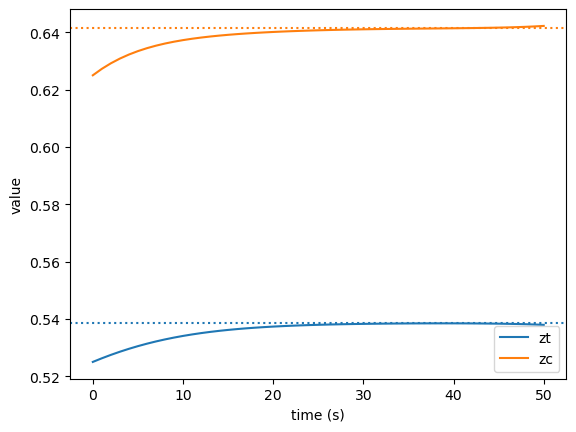

In [4]:
#Plot states

t = m.i.get_finite_elements()      

zc = [value(m.zc[i]) for i in t]
zt = [value(m.zt[i]) for i in t]

# Plot optimal state trajectories
line_zt, = plt.plot(t, zt, label='zt')
line_zc, = plt.plot(t, zc, label='zc')

# Steady-state horizontal lines, matched to each trajectory's color
plt.axhline(m.xss[1], color=line_zc.get_color(), linestyle=':')
plt.axhline(m.xss[2], color=line_zt.get_color(), linestyle=':')


plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()

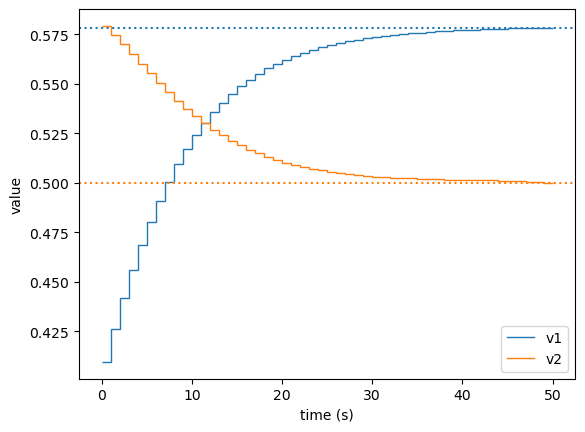

In [5]:
# Plot controls

t = m.i.get_finite_elements()

v1 = [value(m.v1[i]) for i in t[:-1]]
v2 = [value(m.v2[i]) for i in t[:-1]]

# Plot the optimal control trajectories: coolant flow v1 and residence time v2
plt.figure()
line_v1=plt.stairs(v1, t, baseline=None, label='v1')
line_v2=plt.stairs(v2, t, baseline=None, label='v2')

# Steady-state horizontal lines, matched to each trajectory's color
plt.axhline(m.uss[1], color=line_zt.get_color(), linestyle=':')
plt.axhline(m.uss[2], color=line_zc.get_color(), linestyle=':')

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()


In [6]:
for v in (m.v1, m.v2):
    row = [gradient(v[0], wrt=p)
           for p in (m.zcinit, m.ztinit)]
    print(f"d({v.name}[0])/dz(0) = " + "  ".join(f"{g:8.4f}" for g in row))

d(v1[0])/dz(0) =   1.2437   10.8793
d(v2[0])/dz(0) =   1.9014   -6.8014
